# Evaluate DM-Control Hopper

This notebook automatically finds the physical Hopper dataset and trained `InfoLDMAction` and `nextObservation` checkpoints. It evaluates linear probes and available checkpoint-learned nonlinear decoders on the held-out test split, visualizes the data and learned manifolds with UMAP, checks whether the action-conditioned predictors use the full logged action sequence, and compares image reconstructions with the next-observation baseline.

In [ ]:
from __future__ import annotations
import gc
import json
import re
import sys
from collections import defaultdict
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / 'implicit_nuisance').is_dir():
    PROJECT_ROOT = PROJECT_ROOT.parent
if not (PROJECT_ROOT / 'implicit_nuisance').is_dir():
    raise FileNotFoundError('Run this notebook from the implicit_nuisance repository.')
sys.path.insert(0, str(PROJECT_ROOT))

from eval._plotting_style import CAT_COLORS, SEQ_COLORS
from eval.dm_control_hopper_eval import (
    _collect, _find_data_root, _load_config, _load_model, _sequence_subset,
    evaluate_checkpoint,
)
from implicit_nuisance.data import DATASETS
from implicit_nuisance.utils.dm_control_hopper_eval import (
    NUISANCE_NAMES, POSITION_NAMES, TOUCH_NAMES, VELOCITY_NAMES,
)

print('Project root:', PROJECT_ROOT)

In [2]:
RUN_NAME_FILTER = 'dm_control_hopper'  # Set to None to accept every matching run.
LATENT_DIM = 16                                    # Set to None to accept every latent dimensionality.
MAX_RUNS = None                                  # Set to 1 for a quick smoke test.
MAX_PROBE_TRAIN = 10_000
MAX_PROBE_TEST = 10_000
BATCH_SIZE = 16
NUM_WORKERS = 4
RANDOM_SEED = 0
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'

RECONSTRUCTION_SEQUENCE = 4
RECONSTRUCTION_TIMES = (0, 1, 2, 3, 4, 5)
RECONSTRUCTION_LOSSES = ('knn', 'kde', 'logdet')
RECONSTRUCTION_SEED = 1

UMAP_SAMPLES = 2_000
UMAP_N_NEIGHBORS = 30
UMAP_MIN_DIST = 0.1
UMAP_REPRESENTATION = 'inferences'
UMAP_SEED = 1
UMAP_RED_SIGNAL = 'root_height'
UMAP_GREEN_SIGNAL = 'hip'
UMAP_BLUE_SIGNAL = 'torso_pitch_sin'
UMAP_PCA_COMPONENTS = 50

print('Inference device:', DEVICE)

Inference device: cuda


## Find checkpoints and data

The data search checks `DM_CONTROL_HOPPER_ROOT`, the path saved in each run, and the standard `datasets/dm_control_hopper` locations.

In [ ]:
def checkpoint_epoch(path):
    match = re.search(r'ep=(\d+)', path.name)
    return int(match.group(1)) if match else -1


def latest_checkpoint(run):
    checkpoints = list(run['config'].parent.glob('*.ckpt'))
    if not checkpoints:
        raise FileNotFoundError(f"No checkpoints found next to {run['config']}")
    checkpoint = max(
        checkpoints,
        key=lambda path: (checkpoint_epoch(path), path.stat().st_mtime),
    )
    run['checkpoint'] = checkpoint
    run['epoch'] = checkpoint_epoch(checkpoint)
    run['mtime'] = checkpoint.stat().st_mtime
    return checkpoint


def load_run_model(run, cfg):
    # keep_prev=false can remove a discovered checkpoint while training runs
    for attempt in range(2):
        checkpoint = latest_checkpoint(run)
        try:
            return _load_model(checkpoint, cfg, DEVICE)
        except FileNotFoundError:
            if attempt == 1:
                raise


def discover_runs(project_root):
    candidates = []
    for config_path in (project_root / 'trained_models').glob('**/args.json'):
        try:
            config = json.loads(config_path.read_text())
        except (OSError, json.JSONDecodeError):
            continue
        method = config.get('method')
        if method not in {'infoLDMAction', 'nextObservation'}:
            continue
        method_kwargs = config.get('method_kwargs', {})
        if method == 'nextObservation' and not {
            'action_dim', 'rnn_hidden_dim', 'predictor_hidden_dim'
        }.issubset(method_kwargs):
            # Ignore obsolete non-recurrent next-observation checkpoints.
            continue
        if config.get('data', {}).get('dataset') != 'offline_dm_control_hopper_nuisance':
            continue
        state_dim = int(method_kwargs['state_dim'])
        if method != 'nextObservation' and LATENT_DIM is not None and state_dim != LATENT_DIM:
            continue
        name = str(config.get('name', config_path.parent.parent.name))
        if RUN_NAME_FILTER and RUN_NAME_FILTER not in name:
            continue
        checkpoints = list(config_path.parent.glob('*.ckpt'))
        if not checkpoints:
            continue
        checkpoint = max(checkpoints, key=lambda path: (checkpoint_epoch(path), path.stat().st_mtime))
        image_settings = config.get('decoder_kwargs', {}).get('image', {})
        decoder_gradient = not bool(image_settings.get('detach_gradient', True)) or (method == 'nextObservation')
        loss = str(config.get('method_kwargs', {}).get('loss_type', 'next observation'))
        condition = (
            'next observation'
            if method == 'nextObservation'
            else f"{loss} {'attached' if decoder_gradient else 'detached'}"
        )
        candidates.append({
            'name': name,
            'method': method,
            'seed': int(config.get('seed', 0)),
            'state_dim': state_dim,
            'loss': loss,
            'condition': condition,
            'decoder_gradient': decoder_gradient,
            'config': config_path,
            'checkpoint': checkpoint,
            'epoch': checkpoint_epoch(checkpoint),
            'mtime': checkpoint.stat().st_mtime,
            'configured_data_root': config.get('data', {}).get('settings', {}).get('root'),
        })
    latest = {}
    for run in candidates:
        key = (run['name'], run['seed'])
        if key not in latest or (run['mtime'], run['epoch']) > (latest[key]['mtime'], latest[key]['epoch']):
            latest[key] = run
    runs = sorted(latest.values(), key=lambda run: (run['method'] == 'nextObservation', run['loss'], run['decoder_gradient'], run['name']))
    return runs[:MAX_RUNS] if MAX_RUNS is not None else runs


runs = discover_runs(PROJECT_ROOT)
if not runs:
    raise FileNotFoundError(
        f'No completed Hopper checkpoints with LATENT_DIM={LATENT_DIM} were found under trained_models/.'
    )

DATA_ROOT = None
for run in runs:
    try:
        DATA_ROOT = _find_data_root(None, run['configured_data_root'])
        break
    except FileNotFoundError:
        pass
if DATA_ROOT is None:
    DATA_ROOT = _find_data_root(None, None)

print('Dataset root:', DATA_ROOT)
display([{key: value for key, value in run.items() if key not in {'mtime', 'configured_data_root'}} for run in runs])

## Held-out decoding and controlled prediction

The seven-dimensional position target stores root height, sine and cosine of torso pitch, and the four bounded joint angles. Both linear probes and learned nonlinear decoders use this same circular target directly. Velocity and touch are physical state diagnostics; the twelve appearance/camera/light/background variables are view-private nuisance. The action test permutes logged actions while keeping the encoded history fixed. A positive increase in held-out NLL indicates that the predictor actually uses actions.

In [4]:
def evaluate_run(run, cfg):
    return evaluate_checkpoint(
        latest_checkpoint(run), cfg, DATA_ROOT,
        batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, device=DEVICE,
        max_train_samples=MAX_PROBE_TRAIN, max_test_samples=MAX_PROBE_TEST,
        seed=RANDOM_SEED,
    )


results = []
failures = []
for index, run in enumerate(runs, 1):
    print(f"[{index}/{len(runs)}] {run['name']} seed={run['seed']} epoch={run['epoch']}")
    try:
        cfg = _load_config(run['config'])
        metrics = evaluate_run(run, cfg)
        results.append({**run, 'metrics': metrics})
    except Exception as error:
        failures.append({'name': run['name'], 'error': repr(error)})
        print('  FAILED:', repr(error))
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if failures:
    display(failures)
if not results:
    raise RuntimeError('All checkpoint evaluations failed.')

[1/35] dm_control_hopper_kde_16_detachtrue_seed1 seed=1 epoch=39
[2/35] dm_control_hopper_kde_16_detachtrue_seed2 seed=2 epoch=39
[3/35] dm_control_hopper_kde_16_detachtrue_seed3 seed=3 epoch=39
[4/35] dm_control_hopper_kde_16_detachtrue_seed4 seed=4 epoch=39
[5/35] dm_control_hopper_kde_16_detachtrue_seed5 seed=5 epoch=39
[6/35] dm_control_hopper_kde_16_detachfalse_seed1 seed=1 epoch=39
[7/35] dm_control_hopper_kde_16_detachfalse_seed2 seed=2 epoch=39
[8/35] dm_control_hopper_kde_16_detachfalse_seed3 seed=3 epoch=39
[9/35] dm_control_hopper_kde_16_detachfalse_seed4 seed=4 epoch=20
[10/35] dm_control_hopper_kde_16_detachfalse_seed5 seed=5 epoch=39
[11/35] dm_control_hopper_knn_16_detachtrue_seed1 seed=1 epoch=39
[12/35] dm_control_hopper_knn_16_detachtrue_seed2 seed=2 epoch=39
[13/35] dm_control_hopper_knn_16_detachtrue_seed3 seed=3 epoch=39
[14/35] dm_control_hopper_knn_16_detachtrue_seed4 seed=4 epoch=39
[15/35] dm_control_hopper_knn_16_detachtrue_seed5 seed=5 epoch=39
[16/35] dm_con

In [5]:
rename_dict = {
    'kde detached': 'KDE',
    'knn detached': 'kNN',
    'logdet detached': 'logdet',
    'kde attached': 'KDE + decoder',
    'knn attached': 'kNN + decoder',
    'logdet attached': 'logdet + decoder',
    'next observation': 'next observation',
}

summary = []
for result in results:
    metrics = result['metrics']
    controlled_transition = metrics.get('controlled_transition')
    summary.append({
        'condition': rename_dict[result['condition']],
        'loss': result['loss'],
        'decoder gradient': result['decoder_gradient'],
        'position R2': metrics['linear_decoding']['position']['mean'],
        'velocity R2': metrics['linear_decoding']['velocity']['mean'],
        'touch R2': metrics['linear_decoding']['touch']['mean'],
        'nuisance R2': metrics['linear_decoding']['nuisance']['mean'],
        'conditional nuisance delta R2': metrics['conditional_nuisance_leakage']['incremental_r2']['mean'],
        'permuted action delta NLL/dim': (
            controlled_transition['permuted_minus_correct_mean_gaussian_nll_per_dimension']
            if controlled_transition is not None else np.nan
        ),
    })
display(summary)

print(r'\begin{tabular}{lrrrrr}')
print(r'Condition & Position $R^2$ & Velocity $R^2$ & Nuisance $R^2$ & $\Delta R^2_{N\mid S}$ & $\Delta$ NLL/dim \\')
print(r'\hline')
for row in summary:
    condition = row['condition']
    print(f"{condition} & {row['position R2']:.3f} & {row['velocity R2']:.3f} & {row['nuisance R2']:.3f} & {row['conditional nuisance delta R2']:.3f} & {row['permuted action delta NLL/dim']:.3f} \\\\")
print(r'\end{tabular}')

[{'condition': 'KDE',
  'loss': 'kde',
  'decoder gradient': False,
  'position R2': 0.8174056412018835,
  'velocity R2': 0.6253920601875889,
  'touch R2': 0.1968870511007399,
  'nuisance R2': 0.06454609642591004,
  'conditional nuisance delta R2': 0.06637030706207461,
  'permuted action delta NLL/dim': 0.08919045591806829},
 {'condition': 'KDE',
  'loss': 'kde',
  'decoder gradient': False,
  'position R2': 0.8367668982068428,
  'velocity R2': 0.6191302667832111,
  'touch R2': 0.20388168253711286,
  'nuisance R2': 0.08928554773909092,
  'conditional nuisance delta R2': 0.0933081014380917,
  'permuted action delta NLL/dim': 0.08890299296508719},
 {'condition': 'KDE',
  'loss': 'kde',
  'decoder gradient': False,
  'position R2': 0.8409622147220572,
  'velocity R2': 0.6249146050141906,
  'touch R2': 0.19647660221595575,
  'nuisance R2': 0.0571968904345127,
  'conditional nuisance delta R2': 0.058065692937611484,
  'permuted action delta NLL/dim': 0.07772311040795377},
 {'condition': 'KD

\begin{tabular}{lrrrrr}
Condition & Position $R^2$ & Velocity $R^2$ & Nuisance $R^2$ & $\Delta R^2_{N\mid S}$ & $\Delta$ NLL/dim \\
\hline
KDE & 0.817 & 0.625 & 0.065 & 0.066 & 0.089 \\
KDE & 0.837 & 0.619 & 0.089 & 0.093 & 0.089 \\
KDE & 0.841 & 0.625 & 0.057 & 0.058 & 0.078 \\
KDE & 0.851 & 0.655 & 0.058 & 0.061 & 0.095 \\
KDE & 0.818 & 0.625 & 0.084 & 0.087 & 0.084 \\
KDE + decoder & 0.001 & 0.014 & 0.002 & 0.002 & 0.000 \\
KDE + decoder & 0.002 & 0.015 & -0.000 & 0.000 & 0.000 \\
KDE + decoder & -0.001 & 0.012 & 0.001 & 0.002 & 0.000 \\
KDE + decoder & 0.000 & 0.012 & 0.002 & 0.002 & -0.000 \\
KDE + decoder & 0.004 & 0.017 & 0.002 & 0.002 & 0.000 \\
kNN & 0.868 & 0.688 & -0.007 & -0.006 & 0.056 \\
kNN & 0.872 & 0.689 & -0.007 & -0.007 & 0.050 \\
kNN & 0.857 & 0.700 & -0.007 & -0.007 & 0.044 \\
kNN & 0.884 & 0.695 & -0.006 & -0.007 & 0.051 \\
kNN & 0.871 & 0.708 & -0.006 & -0.006 & 0.065 \\
kNN + decoder & 0.006 & 0.019 & 0.010 & 0.010 & 0.000 \\
kNN + decoder & 0.007 & 0.018 & -0.0

## Decoding plots

Signal and nuisance factors are kept in separate panels. The first figure fits linear probes to the recurrent `estimates`; the second scores the checkpoint-learned nonlinear MLP decoders. The recurrent next-observation condition uses the same representations and detached evaluation heads as InfoLDMAction. All scores are evaluated on held-out test frames.

In [ ]:
panels = (
    ('position', POSITION_NAMES, 'Semantic signal'),
    ('velocity', VELOCITY_NAMES, 'Physical velocity'),
    ('nuisance', NUISANCE_NAMES, 'Nuisance'),
)
loss_shades = {'kde': 0.4, 'knn': 0.75, 'logdet': 1.1}
next_observation_color = CAT_COLORS[1]

def shade_color(color, strength):
    color = np.asarray(color)
    return (1.0 - strength * (1.0 - color))

def result_color(result):
    if result['method'] == 'nextObservation':
        return next_observation_color
    base_color = CAT_COLORS[2] if result['decoder_gradient'] else CAT_COLORS[0]
    return shade_color(base_color, loss_shades[result['loss']])

plot_results = sorted(results, key=lambda result: result['decoder_gradient'])
results_by_condition = defaultdict(list)
for result in plot_results:
    results_by_condition[result['condition']].append(result)
plot_groups = list(results_by_condition.items())

def _reformat_name(name):
    name = name.replace("background", "backg. contr.")
    name = name.replace("_", " ")
    return name

fig, axes = plt.subplots(1, 3, figsize=(6, 1.7), sharey=True)
for axis, (key, names, title) in zip(axes, panels):
    x = np.arange(len(names))
    width = 0.8 / len(plot_groups)
    for result_index, (condition, condition_results) in enumerate(plot_groups):
        seed_values = np.asarray([
            [result['metrics']['linear_decoding'][key]['per_dimension'][name] for name in names]
            for result in condition_results
        ])
        values = seed_values.mean(axis=0)
        errors = (
            seed_values.std(axis=0, ddof=1)
            if len(condition_results) > 1 else np.zeros(len(names))
        )
        offset = (result_index - (len(plot_groups) - 1) / 2) * width
        axis.bar(
            x + offset, values, width, yerr=errors, capsize=0.5,
            error_kw={'elinewidth': 0.5, 'capthick': 0.3, 'alpha': 0.5},
            color=result_color(condition_results[0]),
            label=rename_dict[condition],
        )
    # axis.axhline(0, color='black', linewidth=0.8)
    axis.set_xticks([])
    for xi, name in zip(x, names):
        axis.annotate(
            _reformat_name(name),
            xy=(xi, 0),
            xycoords=('data', 'axes fraction'),
            xytext=(-2, 2),
            textcoords='offset points',
            rotation=-45,
            ha='left',
            va='top',
            fontsize=5,
            annotation_clip=False,
        )
    axis.set_title(title, fontsize=6)
    axis.grid(axis='y', alpha=0.2)
axes[0].set_ylabel(r'$R^2$')
axes[-1].legend(bbox_to_anchor=(1.03, 1), loc='upper left')
fig.tight_layout()
plt.savefig("plots/hopper_R2.pdf")


fig, axes = plt.subplots(1, 3, figsize=(6, 1.7), sharey=True)
for axis, (key, names, title) in zip(axes, panels):
    x = np.arange(len(names))
    width = 0.8 / len(plot_groups)
    for result_index, (condition, condition_results) in enumerate(plot_groups):
        seed_values = np.asarray([
            [result['metrics']['nonlinear_decoding'][key]['per_dimension'][name] for name in names]
            for result in condition_results
        ])
        values = seed_values.mean(axis=0)
        errors = (
            seed_values.std(axis=0, ddof=1)
            if len(condition_results) > 1 else np.zeros(len(names))
        )
        offset = (result_index - (len(plot_groups) - 1) / 2) * width
        axis.bar(
            x + offset, values, width, yerr=errors, capsize=0.5,
        error_kw={'elinewidth': 0.5, 'capthick': 0.3, 'alpha': 0.5},
            color=result_color(condition_results[0]),
            label=rename_dict[condition],
        )
    # axis.axhline(0, color='black', linewidth=0.8)
    axis.set_xticks([])
    for xi, name in zip(x, names):
        axis.annotate(
            _reformat_name(name),
            xy=(xi, 0),
            xycoords=('data', 'axes fraction'),
            xytext=(-2, 2),
            textcoords='offset points',
            rotation=-45,
            ha='left',
            va='top',
            fontsize=5,
            annotation_clip=False,
        )
    axis.set_title(title, fontsize=6)
    axis.grid(axis='y', alpha=0.2)
axes[0].set_ylabel(r'Nonlinear $R^2$')
axes[-1].legend(bbox_to_anchor=(1.03, 1), loc='upper left')
fig.tight_layout()
plt.savefig("plots/hopper_nonlinear_R2.pdf")




def _reformat_name(name):
    name = name.replace("background", "backg. contr.")
    name = name.replace("_", " ")
    name = name.replace("torso pitch ", "torso pitch \n")
    return name


key, names, title = panels[0]
fig, axis = plt.subplots(figsize=(5, 1))
group_spacing = 1.25
x = np.arange(len(names)) * group_spacing
width = 0.8 / len(plot_groups)
for result_index, (condition, condition_results) in enumerate(plot_groups):
    seed_values = np.asarray([
        [result['metrics']['linear_decoding'][key]['per_dimension'][name] for name in names]
        for result in condition_results
    ])
    values = seed_values.mean(axis=0)
    errors = (
        seed_values.std(axis=0, ddof=1)
        if len(condition_results) > 1 else np.zeros(len(names))
    )
    offset = (result_index - (len(plot_groups) - 1) / 2) * width
    axis.bar(
        x + offset, values, width, yerr=errors, capsize=0.5,
        error_kw={'elinewidth': 0.5, 'capthick': 0.3, 'alpha': 0.5},
        color=result_color(condition_results[0]),
        label=rename_dict[condition],
    )
# axis.axhline(0, color='black', linewidth=0.8)
axis.set_xlim(x[0] - 0.45, x[-1] + 0.45)
axis.set_xticks([])
for xi, name in zip(x, names):
    axis.annotate(
        _reformat_name(name),
        xy=(xi, 0),
        xycoords=('data', 'axes fraction'),
        xytext=(-2, -4),
        textcoords='offset points',
        rotation=-0,
        ha='center',
        va='top',
        fontsize=5,
        annotation_clip=False,
    )
axis.set_ylabel(r'$R^2$')
axis.grid(axis='y', alpha=0.2)
axis.legend(bbox_to_anchor=(1.03, 1), loc='upper left')
fig.tight_layout()
plt.savefig("plots/hopper_nonlinear_R2_main.pdf")

In [ ]:
def _reformat_name(name):
    name = name.replace("background", "backg. contr.")
    name = name.replace("_", " ")
    return name

rename_dict2 = {
    'logdet detached': 'latent predictive',
    'logdet attached': 'generative',
    'next observation': 'next observation',
    
}

key, names, title = panels[0]
fig, axis = plt.subplots(figsize=(3, 1.3))
x = np.arange(len(names))
talk_results = [
    result for result in plot_results
    if 'logdet' in result['condition'] or 'next' in result['condition']
]
talk_results_by_condition = defaultdict(list)
for result in talk_results:
    talk_results_by_condition[result['condition']].append(result)
talk_groups = list(talk_results_by_condition.items())
width = 0.8 / len(talk_groups)
for result_index, (condition, condition_results) in enumerate(talk_groups):
    seed_values = np.asarray([
        [result['metrics']['linear_decoding'][key]['per_dimension'][name] for name in names]
        for result in condition_results
    ])
    values = seed_values.mean(axis=0)
    errors = (
        seed_values.std(axis=0, ddof=1)
        if len(condition_results) > 1 else np.zeros(len(names))
    )
    offset = (result_index - (len(talk_groups) - 1) / 2) * width
    axis.bar(
        x + offset, values, width, yerr=errors, capsize=1.0,
        error_kw={'elinewidth': 0.5, 'capthick': 0.3, 'alpha': 0.5},
        color=result_color(condition_results[0]),
        label=rename_dict2[condition],
    )
# axis.axhline(0, color='black', linewidth=0.8)
axis.set_xticks([])
axis.set_xticklabels([])
for xi, name in zip(x, names):
    axis.annotate(
        _reformat_name(name),
        xy=(xi, 0),
        xycoords=('data', 'axes fraction'),
        xytext=(-2, -4),
        textcoords='offset points',
        rotation=-45,
        ha='left',
        va='top',
        fontsize=5,
        annotation_clip=False,
    )
axis.set_ylabel(r'$R^2$')
axis.grid(axis='y', alpha=0.2)
axis.legend(bbox_to_anchor=(1.03, 1), loc='upper left')
fig.tight_layout()
plt.savefig("plots/hopper_talk.pdf")

## UMAP manifolds

The two data references embed the seven-dimensional circular position readout and the full-resolution normalized images, respectively. Images retain all 128×128 pixels and are reduced to at most `UMAP_PCA_COMPONENTS` dimensions with randomized PCA before UMAP. Every learned-condition panel embeds the selected representation from the same held-out frames. Point color jointly encodes two position variables: `UMAP_RED_SIGNAL` controls red intensity and `UMAP_BLUE_SIGNAL` controls blue intensity. Because UMAP coordinates are fitted independently, compare neighborhood and color organization rather than absolute orientation between panels.

In [ ]:
from matplotlib.patches import Patch
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from umap import UMAP

if UMAP_RED_SIGNAL not in POSITION_NAMES or UMAP_BLUE_SIGNAL not in POSITION_NAMES:
    raise ValueError(f'UMAP color signals must be chosen from {POSITION_NAMES}')

def collect_image_manifold(dataset):
    subset = _sequence_subset(dataset, UMAP_SAMPLES, RANDOM_SEED + 1)
    rows = []
    for images, _ in subset:
        rows.append(images.flatten(start_dim=1).numpy())
    values = np.concatenate(rows)
    keep = np.random.default_rng(RANDOM_SEED + 1010).permutation(len(values))
    return values[keep[:UMAP_SAMPLES]]

manifold_runs = [result for result in results if result['seed'] == UMAP_SEED]
if not manifold_runs:
    raise RuntimeError(f'No evaluated runs have UMAP_SEED={UMAP_SEED}.')
manifold_inputs = {}
manifold_position = None
manifold_images = None
for index, result in enumerate(manifold_runs, 1):
    title = rename_dict[result['condition']]
    print(f'[{index}/{len(manifold_runs)}] Collecting {title}')
    cfg = _load_config(result['config'])
    cfg.data.settings.root = str(DATA_ROOT)
    cfg.device = DEVICE
    model = load_run_model(result, cfg)
    dataset = DATASETS[cfg.data.dataset](cfg, split='test')
    arrays, _ = _collect(
        model, dataset, maximum=UMAP_SAMPLES, selection_seed=RANDOM_SEED + 1,
        representation_key=UMAP_REPRESENTATION, batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS, device=DEVICE, transitions=False,
    )
    if manifold_position is None:
        manifold_position = arrays['position']
        manifold_images = collect_image_manifold(dataset)
    else:
        np.testing.assert_allclose(arrays['position'], manifold_position)
    manifold_inputs[title] = arrays['z']
    del model, dataset, arrays
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

if manifold_position is None:
    raise RuntimeError('No representations were collected for UMAP.')
manifold_inputs = {
    'Data — signal': manifold_position,
    'Data — image': manifold_images,
    **manifold_inputs,
}

def umap_projection(values):
    pca_components = min(
        UMAP_PCA_COMPONENTS, values.shape[0] - 1, values.shape[1],
    )
    if values.shape[1] > pca_components:
        prepared = PCA(
            n_components=pca_components, svd_solver='randomized', whiten=True,
            random_state=RANDOM_SEED,
        ).fit_transform(values)
    else:
        prepared = StandardScaler().fit_transform(values)
    neighbors = min(UMAP_N_NEIGHBORS, len(prepared) - 1)
    return UMAP(
        n_components=2, n_neighbors=neighbors, min_dist=UMAP_MIN_DIST,
        random_state=RANDOM_SEED,
    ).fit_transform(prepared)

def color_channel(values):
    lower, upper = np.quantile(values, (0.01, 0.99))
    if upper <= lower:
        return np.full_like(values, 0.5, dtype=np.float64)
    return np.clip((values - lower) / (upper - lower), 0.0, 1.0)

red_index = POSITION_NAMES.index(UMAP_RED_SIGNAL)
green_index = POSITION_NAMES.index(UMAP_GREEN_SIGNAL)
blue_index = POSITION_NAMES.index(UMAP_BLUE_SIGNAL)
point_colors = np.zeros((len(manifold_position), 3), dtype=np.float64)
point_colors[:, 0] = color_channel(manifold_position[:, red_index])
point_colors[:, 1] = color_channel(manifold_position[:, green_index])
point_colors[:, 2] = color_channel(manifold_position[:, blue_index])

projections = {}
for index, (title, values) in enumerate(manifold_inputs.items(), 1):
    print(f'[{index}/{len(manifold_inputs)}] Fitting UMAP for {title}')
    projections[title] = umap_projection(values)



/tmp/ipykernel_3195389/3646929163.py:22: UserWarning: The figure layout has changed to tight
  fig.tight_layout(h_pad=2,w_pad=3)


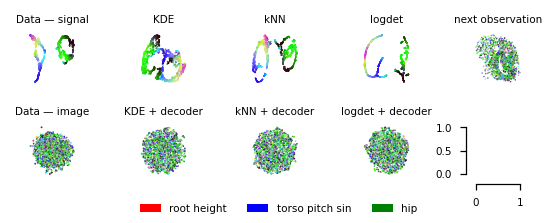

In [9]:
columns = 5
rows = int(np.ceil(len(projections) / columns))
fig, axes = plt.subplots(rows, columns, figsize=(0.7 * columns, 0.7 * rows), squeeze=False)
flat_axes = axes.ravel(order='F')
for axis, (title, projection) in zip(flat_axes, projections.items()):
    axis.scatter(
        projection[:, 0], projection[:, 1], c=point_colors,
        s=0.5, alpha=0.75, linewidths=0, rasterized=True, clip_on=False
    )
    axis.set_title(title, fontsize=5)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_frame_on(False)
fig.legend(
    handles=(
        Patch(facecolor='red', label=UMAP_RED_SIGNAL.replace("_"," ")),
        Patch(facecolor='blue', label=UMAP_BLUE_SIGNAL.replace("_"," ")),
        Patch(facecolor='green', label=UMAP_GREEN_SIGNAL.replace("_"," ")),
    ),
    loc='lower center', ncol=3, frameon=False,
)
fig.tight_layout(h_pad=2,w_pad=3)
fig.savefig("plots/hopper_umap.pdf", dpi=600)

## Reconstruction and next-observation comparison

Every row uses the same held-out physical rollout. “Detached” trains the image decoder without allowing its loss to change the encoder; “attached” allows reconstruction gradients into the representation. The recurrent next-observation model has a detached current-frame evaluation decoder and a separate attached prediction decoder mapping the action-conditioned predicted representation at time `t` to frame `t + 1`.

/tmp/ipykernel_3195389/1722840082.py:119: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


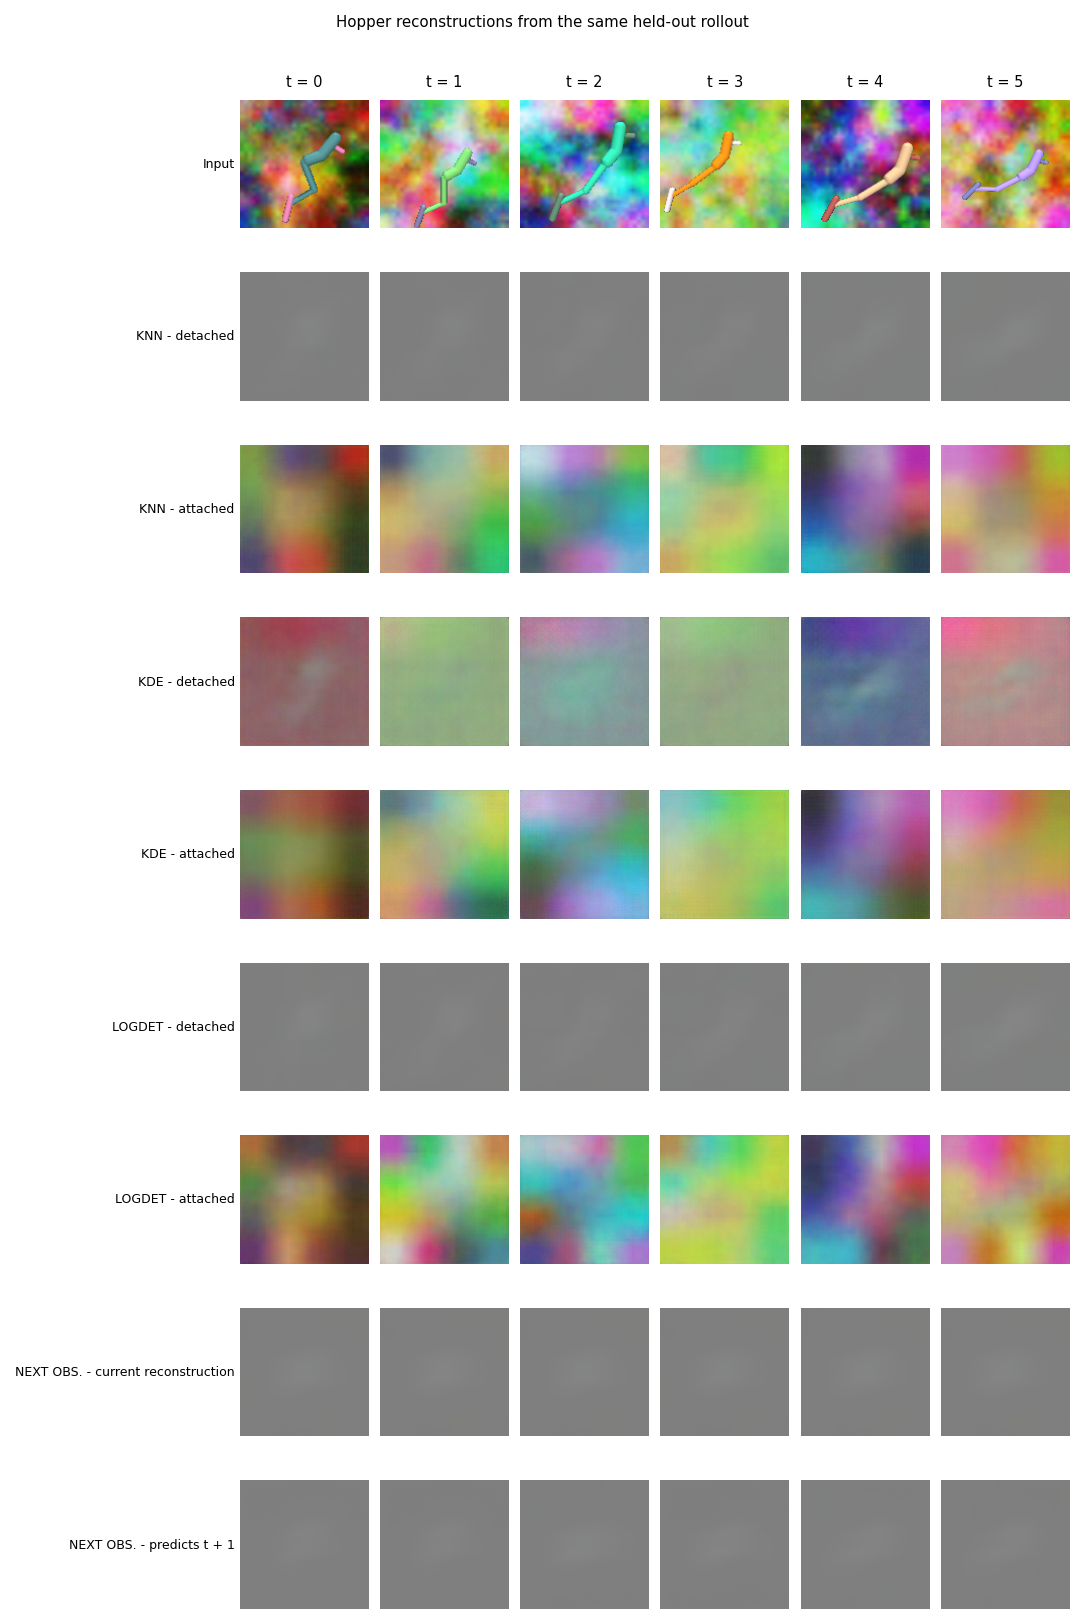

In [10]:

def to_rgb(images, normalization):
    images = images.detach().cpu().float()
    if str(normalization).lower() == 'imagenet':
        mean = torch.tensor((0.485, 0.456, 0.406))[None, :, None, None]
        std = torch.tensor((0.229, 0.224, 0.225))[None, :, None, None]
        images = images * std + mean
    elif str(normalization).lower() in {'minus_one_one', '-1_1'}:
        images = images * 0.5 + 0.5
    return images.clamp(0, 1).permute(0, 2, 3, 1).numpy()


matched = {}
for loss in RECONSTRUCTION_LOSSES:
    groups = defaultdict(dict)
    for run in runs:
        if (
            run['method'] == 'infoLDMAction'
            and run['loss'] == loss
            and run['seed'] == RECONSTRUCTION_SEED
        ):
            groups[(run['state_dim'], run['seed'])][run['decoder_gradient']] = run
    complete = [pair for pair in groups.values() if set(pair) == {False, True}]
    if complete:
        matched[loss] = max(complete, key=lambda pair: min(item['mtime'] for item in pair.values()))
if not matched:
    raise RuntimeError('No matched detached/attached image-decoder checkpoint pairs were found.')
next_observation_runs = [
    run for run in runs
    if run['method'] == 'nextObservation' and run['seed'] == RECONSTRUCTION_SEED
]
next_observation_run = (
    max(next_observation_runs, key=lambda run: (run['mtime'], run['epoch']))
    if next_observation_runs else None
)

reconstructions = {}
original = None
valid_times = None
for loss, pair in matched.items():
    for attached, run in pair.items():
        cfg = _load_config(run['config'])
        cfg.data.settings.root = str(DATA_ROOT)
        cfg.device = DEVICE
        model = load_run_model(run, cfg)
        dataset = DATASETS[cfg.data.dataset](cfg, split='test')
        images, targets = dataset[RECONSTRUCTION_SEQUENCE]
        valid_times = tuple(time for time in RECONSTRUCTION_TIMES if 0 <= time < images.shape[0])
        with torch.inference_mode():
            output = model(images[None].to(DEVICE), targets['actions'][None].to(DEVICE))
        if 'image' not in output['target_estimates']:
            raise KeyError(f"{run['name']} has no image decoder output")
        normalization = cfg.data.settings.normalization
        if original is None:
            original = to_rgb(images[list(valid_times)], normalization)
        decoded = output['target_estimates']['image'][0, list(valid_times)]
        reconstructions[(loss, attached)] = to_rgb(decoded, normalization)
        del model, output
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

if next_observation_run is not None:
    run = next_observation_run
    cfg = _load_config(run['config'])
    cfg.data.settings.root = str(DATA_ROOT)
    cfg.device = DEVICE
    model = load_run_model(run, cfg)
    dataset = DATASETS[cfg.data.dataset](cfg, split='test')
    images, targets = dataset[RECONSTRUCTION_SEQUENCE]
    with torch.inference_mode():
        output = model(
            images[None].to(DEVICE),
            targets['actions'][None].to(DEVICE),
        )
    current_decoded = output['target_estimates']['image'][0]
    next_decoded = output['target_estimates']['next_image'][0]
    if any(time >= next_decoded.shape[0] for time in valid_times):
        raise ValueError('A requested next-observation prediction has no saved successor.')
    reconstructions[('next observation', 'current')] = to_rgb(
        current_decoded[list(valid_times)], cfg.data.settings.normalization,
    )
    reconstructions[('next observation', 'predicted')] = to_rgb(
        next_decoded[list(valid_times)], cfg.data.settings.normalization,
    )
    del model, output
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

row_specs = [('Input', original)]
for loss in RECONSTRUCTION_LOSSES:
    if loss in matched:
        row_specs.extend([
            (f'{loss.upper()} - detached', reconstructions[(loss, False)]),
            (f'{loss.upper()} - attached', reconstructions[(loss, True)]),
        ])
if next_observation_run is not None:
    row_specs.extend([
        (
            'NEXT OBS. - current reconstruction',
            reconstructions[('next observation', 'current')],
        ),
        (
            'NEXT OBS. - predicts t + 1',
            reconstructions[('next observation', 'predicted')],
        ),
    ])

fig, axes = plt.subplots(len(row_specs), len(valid_times), figsize=(1.2 * len(valid_times), 1.2 * len(row_specs)), squeeze=False)
for row, (label, row_images) in enumerate(row_specs):
    for column, (time, image) in enumerate(zip(valid_times, row_images)):
        axes[row, column].imshow(image)
        axes[row, column].axis('off')
        if row == 0:
            axes[row, column].set_title(f't = {time}')
        if column == 0:
            axes[row, column].text(-0.04, 0.5, label, transform=axes[row, column].transAxes, ha='right', va='center')
fig.suptitle('Hopper reconstructions from the same held-out rollout', y=1.002)
fig.tight_layout()
fig.savefig("plots/hopper_recnostructions_all.pdf")

/tmp/ipykernel_3195389/1115192607.py:13: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


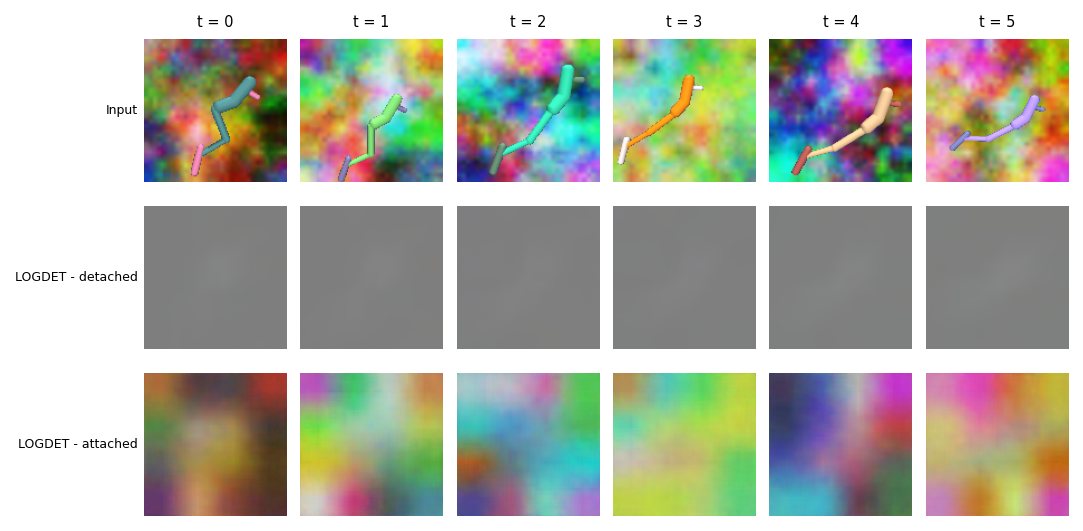

In [11]:

fig, axes = plt.subplots(3, len(valid_times), figsize=(1.2 * len(valid_times), 1.2 * 3), squeeze=False)
i=0
for row, (label, row_images) in enumerate(row_specs):
    if "Input" in label or "LOGDET" in label:
        for column, (time, image) in enumerate(zip(valid_times, row_images)):
            axes[i, column].imshow(image)
            axes[i, column].axis('off')
            if i == 0:
                axes[i, column].set_title(f't = {time}')
            if column == 0:
                axes[i, column].text(-0.04, 0.5, label, transform=axes[i, column].transAxes, ha='right', va='center')
        i += 1
fig.tight_layout()
fig.savefig("plots/hopper_recnostructions_main.pdf")